In [1]:
pip install pandas numpy matplotlib scikit-learn statsmodels jupyter


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Load your CSV
df = pd.read_csv(r"C:\Users\abc\Desktop\ADV quiz 3 and 4\Bitcoin-data.csv")

# Check columns
print(df.columns)
print(df.head())
print(df.shape)

Index(['Date', 'Price_USD', 'Volume_USD', 'MarketCap_USD', 'Growth_Rate_%'], dtype='object')
                  Date     Price_USD    Volume_USD  MarketCap_USD  \
0  2026-02-06 00:00:00  62853.690384  1.424032e+11   1.262033e+12   
1  2026-02-25 00:00:00  64074.110985  4.486448e+10   1.281148e+12   
2  2026-02-24 00:00:00  64577.553201  5.672440e+10   1.291179e+12   
3  2026-03-02 00:00:00  65713.498989  4.346749e+10   1.314049e+12   
4  2026-02-28 00:00:00  65883.990962  4.303196e+10   1.317715e+12   

   Growth_Rate_%  
0     -40.561310  
1     -39.407198  
2     -38.931109  
3     -37.856882  
4     -37.695653  
(366, 5)


In [4]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Keep only needed columns
df = df[['Date', 'Price_USD']].dropna()

print(df.head())
print(f"Total rows: {len(df)}")

        Date      Price_USD
0 2025-05-30  105745.416604
1 2025-05-31  104010.919562
2 2025-06-01  104687.507429
3 2025-06-02  105710.005938
4 2025-06-03  105884.742632
Total rows: 366


In [5]:
# Time-based features
df['Day_Index'] = range(len(df))
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Day_of_Week'] = df['Date'].dt.dayofweek

# Lag features
df['Lag_1'] = df['Price_USD'].shift(1)
df['Lag_7'] = df['Price_USD'].shift(7)
df['Rolling_Mean_7'] = df['Price_USD'].rolling(window=7).mean()
df['Rolling_Std_7'] = df['Price_USD'].rolling(window=7).std()

# Drop nulls created by lag
df = df.dropna().reset_index(drop=True)

print(df.head())
print(f"Rows after feature engineering: {len(df)}")

        Date      Price_USD  Day_Index  Year  Month  Quarter  Day_of_Week  \
0 2025-06-06  101650.738755          7  2025      6        2            4   
1 2025-06-07  104409.749680          8  2025      6        2            5   
2 2025-06-08  105681.454614          9  2025      6        2            6   
3 2025-06-09  105692.247407         10  2025      6        2            0   
4 2025-06-10  110261.574859         11  2025      6        2            1   

           Lag_1          Lag_7  Rolling_Mean_7  Rolling_Std_7  
0  104812.918219  105745.416604   104598.758570    1453.568483  
1  101650.738755  104010.919562   104655.734301    1434.376406  
2  104409.749680  104687.507429   104797.726756    1486.302665  
3  105681.454614  105710.005938   104795.189823    1484.500057  
4  105692.247407  105884.742632   105420.451569    2555.387015  
Rows after feature engineering: 359


In [6]:
split = int(len(df) * 0.8)
train = df[:split]
test = df[split:]

print(f"Training rows: {len(train)}")
print(f"Testing rows:  {len(test)}")

Training rows: 287
Testing rows:  72


In [7]:
features = ['Day_Index', 'Month', 'Quarter', 'Lag_1', 'Lag_7', 'Rolling_Mean_7']

X_train = train[features]
y_train = train['Price_USD']
X_test  = test[features]
y_test  = test['Price_USD']

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("=== Linear Regression Results ===")
print(f"MAE:  {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R²:   {lr_r2:.4f}")

=== Linear Regression Results ===
MAE:  1096.61
RMSE: 1344.77
R²:   0.9115


In [8]:
train_series = train['Price_USD'].values

arima_model = ARIMA(train_series, order=(5,1,0))
arima_fit   = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

arima_mae  = mean_absolute_error(y_test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))
arima_r2   = r2_score(y_test, arima_pred)

print("=== ARIMA Results ===")
print(f"MAE:  {arima_mae:.2f}")
print(f"RMSE: {arima_rmse:.2f}")
print(f"R²:   {arima_r2:.4f}")

=== ARIMA Results ===
MAE:  4987.09
RMSE: 5716.53
R²:   -0.5986


In [9]:
future_steps = 90

# Forecast test + future together then slice
full_forecast = arima_fit.forecast(steps=len(test) + future_steps)
future_forecast = full_forecast[len(test):]

# Generate future dates
last_date    = df['Date'].max()
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1), 
    periods=future_steps
)

future_df = pd.DataFrame({
    'Date': future_dates,
    'Price': future_forecast,
    'Type': 'Forecast'
})

print(future_df.head(10))

        Date         Price      Type
0 2026-05-30  71159.928644  Forecast
1 2026-05-31  71159.928644  Forecast
2 2026-06-01  71159.928644  Forecast
3 2026-06-02  71159.928644  Forecast
4 2026-06-03  71159.928644  Forecast
5 2026-06-04  71159.928644  Forecast
6 2026-06-05  71159.928644  Forecast
7 2026-06-06  71159.928644  Forecast
8 2026-06-07  71159.928644  Forecast
9 2026-06-08  71159.928644  Forecast


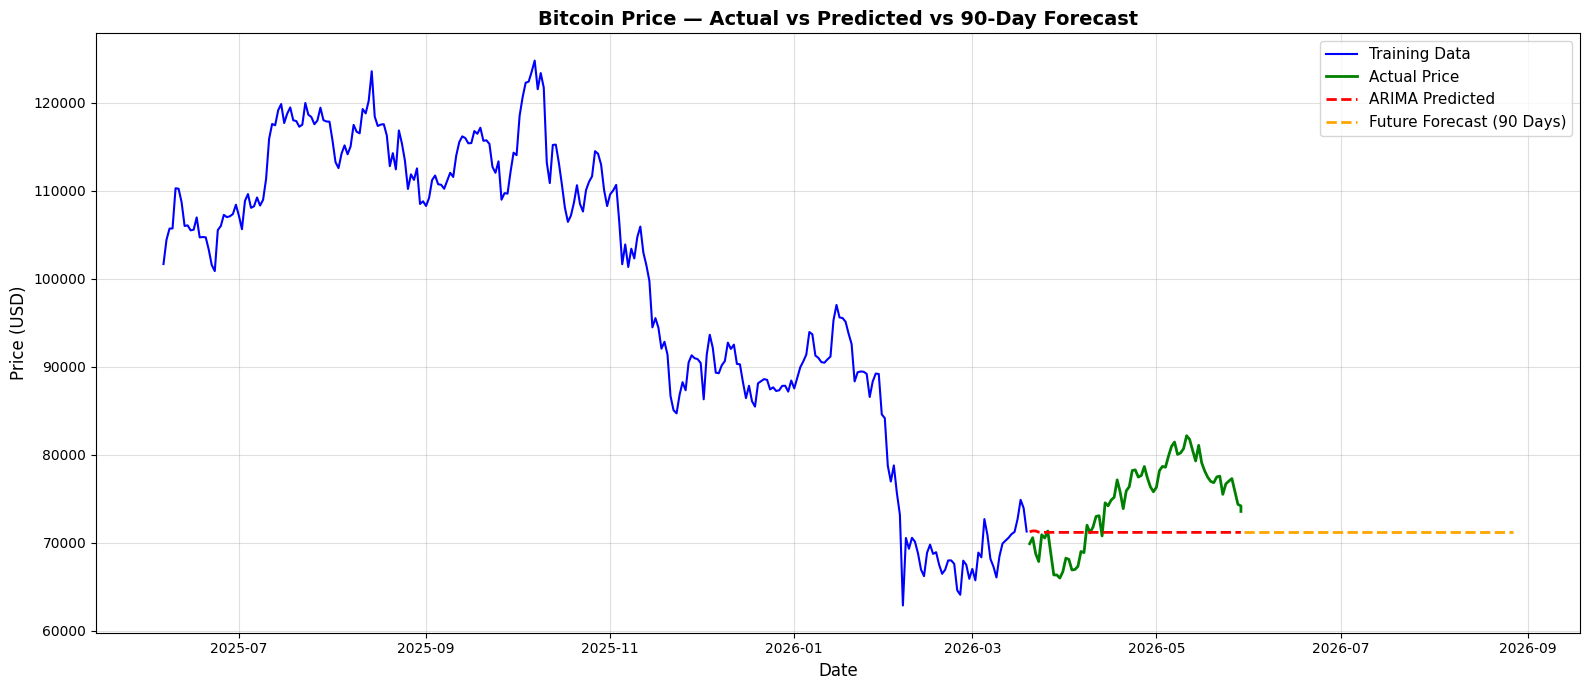

Plot saved!


In [10]:
plt.figure(figsize=(16, 7))

plt.plot(train['Date'], train['Price_USD'],
         label='Training Data', color='blue', linewidth=1.5)

plt.plot(test['Date'], test['Price_USD'],
         label='Actual Price', color='green', linewidth=2)

plt.plot(test['Date'], arima_pred,
         label='ARIMA Predicted', color='red', 
         linestyle='--', linewidth=2)

plt.plot(future_dates, future_forecast,
         label='Future Forecast (90 Days)', color='orange', 
         linestyle='--', linewidth=2)

plt.title('Bitcoin Price — Actual vs Predicted vs 90-Day Forecast', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()

# Save to your folder
plt.savefig(
    r"C:\Users\abc\Desktop\ADV quiz 3 and 4\bitcoin_forecast.png", 
    dpi=150
)
plt.show()
print("Plot saved!")

In [11]:
# --- Actual data ---
actual_df = df[['Date', 'Price_USD']].copy()
actual_df.rename(columns={'Price_USD': 'Price'}, inplace=True)
actual_df['Type'] = 'Actual'

# --- Predicted data ---
pred_df = test[['Date']].copy()
pred_df['Price'] = arima_pred
pred_df['Type']  = 'Predicted'

# --- Combine all ---
final_df = pd.concat([actual_df, pred_df, future_df], ignore_index=True)

# Save forecast CSV
final_df.to_csv(
    r"C:\Users\abc\Desktop\ADV quiz 3 and 4\bitcoin_forecast.csv", 
    index=False
)
print("bitcoin_forecast.csv saved!")

# --- Metrics table ---
metrics_df = pd.DataFrame({
    'Model':    ['Linear Regression', 'ARIMA'],
    'MAE':      [round(lr_mae, 2),    round(arima_mae, 2)],
    'RMSE':     [round(lr_rmse, 2),   round(arima_rmse, 2)],
    'R2_Score': [round(lr_r2, 4),     round(arima_r2, 4)]
})

metrics_df.to_csv(
    r"C:\Users\abc\Desktop\ADV quiz 3 and 4\model_metrics.csv", 
    index=False
)
print("model_metrics.csv saved!")
print(metrics_df)

bitcoin_forecast.csv saved!
model_metrics.csv saved!
               Model      MAE     RMSE  R2_Score
0  Linear Regression  1096.61  1344.77    0.9115
1              ARIMA  4987.09  5716.53   -0.5986
